In [ ]:
import math
import numpy as np
import pandas as pd 
import matplotlib as plt 
import matplotlib.pyplot as plt
%matplotlib inline
import scipy 
from scipy import stats
import zipfile
import os
import sif_parser
from scipy.signal import find_peaks
import lmfit
from lmfit import Model, Parameters, Minimizer
from lmfit.models import GaussianModel, VoigtModel, LinearModel


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
#expecting a relatively intense peak around 401.22 nm, should be more pronounced as moving up in concentration. 
# his makes me think the wavelength calibration is not as accurate as it should be 
folder_path_DP = "DP/DP"
sif_files_DP = [f for f in os.listdir(folder_path_DP) if f.endswith('.sif')]

for file_name in sif_files_DP[:13]: #From Gemini, I am not familiar with sif files but seems to work fine
    file_path = os.path.join(folder_path_DP, file_name)
    data, info = sif_parser.np_open(file_path)
    
    if data.ndim == 3:
        image_2d = data[0]
    else:
        image_2d = data
        
    #Make it 1D. plasma aspects seem to be from pixels 500 to 600
    y_start = 512
    y_end = 600
    plasma_slice = image_2d[y_start:y_end, :]
    spectrum = np.sum(plasma_slice, axis=0)
        
    #Wavelength Calibration, needs some fixing .. Potassium doublet, would be nice to know the large peak below 400 nm to fix the 
    #other coefficients and be more accurate below the 404 nm range, looking around 401.22 nm. 
    pixels = np.arange(1, len(spectrum) + 1)
    
    coeffs = [381.02184936261204 +.15, 0.037033476478940355, 0.0, 0.0] 
        
    wavelengths = (coeffs[0] + 
                   (coeffs[1] * pixels) + 
                   (coeffs[2] * (pixels**2)) + 
                   (coeffs[3] * (pixels**3)))
# ... [keep your previous code up to generating the wavelengths] ...

    # --- DYNAMIC PEAK FINDER ---
    
    # 1. Define a tight search window around where we know the peak lives
    search_min, search_max = 401.0, 401.5
    
    # 2. Create a mask to only look at data inside this window
    peak_mask = (wavelengths >= search_min) & (wavelengths <= search_max)
    
    # 3. Slice the data
    window_wavelengths = wavelengths[peak_mask]
    window_intensities = spectrum[peak_mask]
    
    if len(window_intensities) > 0: # Safety check to ensure the window isn't empty
        # 4. Find the INDEX of the maximum intensity in this slice
        max_index = np.argmax(window_intensities)
        
        # 5. Use that index to find the exact wavelength and intensity
        actual_nd_wavelength = window_wavelengths[max_index]
        actual_nd_intensity = window_intensities[max_index]
        
        print(f"File {file_name}: Found actual Nd peak at {actual_nd_wavelength:.2f} nm")
    else:
        actual_nd_wavelength = 401.50 # Fallback just in case
    

     
    plt.figure(figsize=(10, 4))
    plt.plot(wavelengths, spectrum, color='blue', linewidth=1)
    #
    # 4. Plot it!

    
    # Add vertical lines for knowns
    plt.axvline(x=393.366, color='darkred', linestyle='--', alpha=0.6, label='Ca II (393.37)')
    plt.axvline(x=396.847, color='red', linestyle='--', alpha=0.6, label='Ca II (396.847)')
    
    # Potassium Doublet
    plt.axvline(x=404.414, color='darkgreen', linestyle='--', alpha=0.6, label='K I (404.41)')
    plt.axvline(x=404.721, color='green', linestyle='--', alpha=0.6, label='K I (404.72)')
    
    # Add our DYNAMIC vertical line for the real Nd peak
    plt.axvline(x=actual_nd_wavelength, color='magenta', linestyle='-', alpha=0.8, 
                label=f'Dynamic Nd ({actual_nd_wavelength:.2f})')
    
    plt.title(f"Calibrated DP LIBS Spectrum: {file_name}")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity (Counts)")
    plt.legend()
    
    # --- DYNAMIC AXIS SCALING (From earlier!) ---

    plt.grid(True, alpha=0.3)
    plt.show()
    plt.close()

In [ ]:
folder_path_DP = "DP/DP"
sif_files_DP = [f for f in os.listdir(folder_path_DP) if f.endswith('.sif')]

# Open the first file
file_name = sif_files_DP[0]
file_path = os.path.join(folder_path_DP, file_name)
data, info = sif_parser.np_open(file_path)

# Handle the data shape (grab the first frame if it's a 3D accumulation stack)
if data.ndim == 3:
    image_2d = data[0]
else:
    image_2d = data

# Plot the 2D image!
plt.figure(figsize=(8, 6))

# We use percentiles for vmin/vmax to fix the contrast. 
# Otherwise, one super bright pixel makes the rest of the image look black.
plt.imshow(image_2d, cmap='viridis', aspect='auto', origin='lower', 
           vmin=np.percentile(image_2d, 5), vmax=np.percentile(image_2d, 99))

plt.colorbar(label='Intensity (Counts)')
plt.title(f"Raw 2D Camera Image: {file_name}")
plt.xlabel("X-Axis (Pixels)")
plt.ylabel("Y-Axis (Pixels)")
plt.show()

In [5]:
file_path = "INL_LIBS_Data_Extracted_DP/DP/DP_1000ppm_25_spot_scan_3.sif" 

# 2. Open the file (this separates the binary into 'data' and 'info')
data, info = sif_parser.np_open(file_path)

# 3. Print out a list of just the categories (keys) available:
print("--- AVAILABLE METADATA KEYS ---")
print(list(info.keys()))
print("\n")

# 4. Print out absolutely everything inside the dictionary neatly:
print("--- FULL EXPERIMENT INFO ---")
for key, value in info.items():
    print(f"{key}: {value}")

FileNotFoundError: [Errno 2] No such file or directory: 'INL_LIBS_Data_Extracted_DP/DP/DP_1000ppm_25_spot_scan_3.sif'

In [ ]:
# You can change this to your SP folder path when you are ready to run those!
base_folder = os.path.join('DP', 'DP')

files_to_plot = {
    'DP_5ppm_25_spot_scan.sif': '5 ppm Nd',
    'DP_10ppm_25_spot_scan_1.sif': '10 ppm Nd',
    'DP_50ppm_25_spot_scan.sif': '50 ppm Nd', #I think this was contaminated!
    'DP_100ppm_25_spot_scan_1_old.sif': '100 ppm Nd',
    'DP_500ppm_25_spot_scan_old.sif': '500 ppm Nd',
    'DP_1000ppm_25_spot_scan_3.sif': '1000 ppm Nd',
    'DP_2000ppm_25_spot_scan.sif': '2000 ppm Nd',
    'DP_4000ppm_25_spot_scan.sif': '4000 ppm Nd',
    'DP_blank_25_spot_scan.sif': 'Blank Sample'
}

# The PI's exact dispersion coefficients
coeffs = [381.02184936261204, 0.037033476478940355, 0.0, 0.0]

colors = plt.cm.viridis(np.linspace(0, 1, len(files_to_plot)))

for (filename, label), color in zip(files_to_plot.items(), colors):
    file_path = os.path.join(base_folder, filename)
    
    # --- SMART DRIFT DETECTION ---
    if 'DP' in filename:
        drift_offset = 0.15
    elif 'SP' in filename:
        drift_offset = 0.27
    else:
        drift_offset = 0.0
        
    data, info = sif_parser.np_open(file_path)
    
    # Dimension check and plasma slicing
    image_2d = data[0] if data.ndim == 3 else data
    plasma_slice = image_2d[500:600, :] 
    spectrum = np.sum(plasma_slice, axis=0)
    
    # Apply Calibration + Automatic Drift
    pixels = np.arange(1, len(spectrum) + 1)
    wavelengths = coeffs[0] + (coeffs[1] * pixels) + drift_offset
    
    # Plotting
    plt.figure(figsize=(10, 4))
    plt.plot(wavelengths, spectrum, linewidth=1.5, color=color, label=label)

    # Reference Lines
    plt.axvline(x=393.37, color='red', linestyle='--', alpha=0.5, label='Ca (393.37nm)') #NIST
    plt.axvline(x=396.85, color='red', linestyle='--', alpha=0.5, label='Ca (396.85nm)') #NIST
    plt.axvline(x=404.41, color='green', linestyle='--', alpha=0.5, label='K (404.41nm)') #NIST
    plt.axvline(x=404.72, color='green', linestyle='--', alpha=0.5, label='K (404.72nm)') #NIST
    plt.axvline(x=401.225, color='blue', linestyle='--', alpha=0.5, label='Nd (401.225nm)') 

    plt.title(f"Double Pulse LIBS: {label} (Drift: +{drift_offset}nm)")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity (Counts)")
    
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.show()

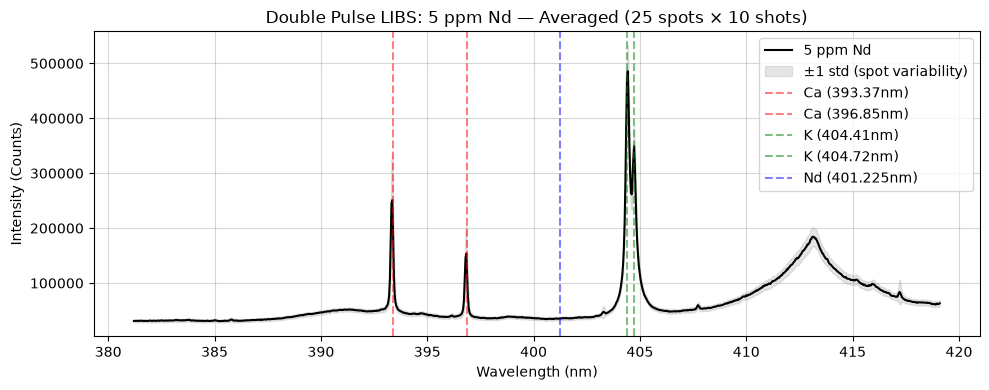

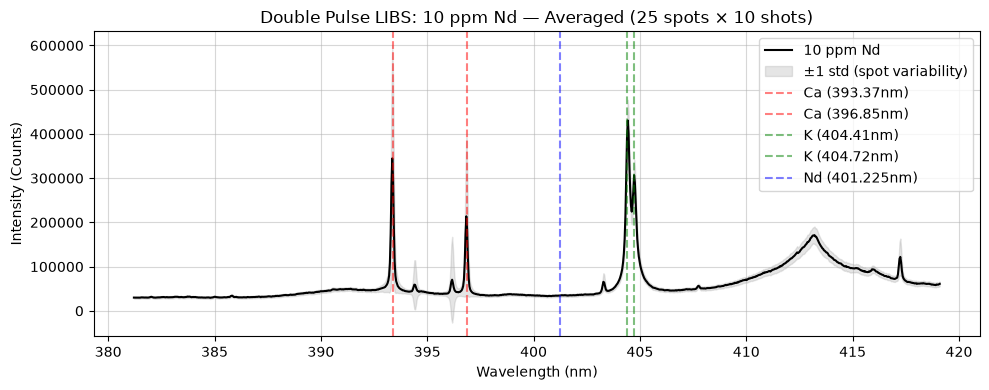

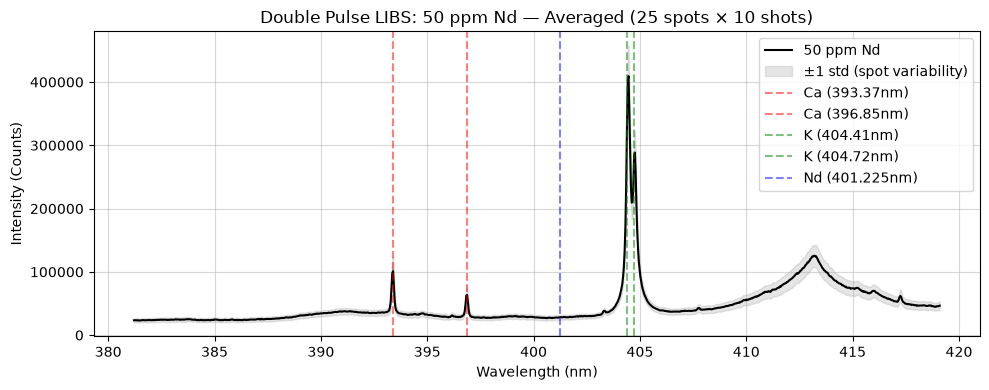

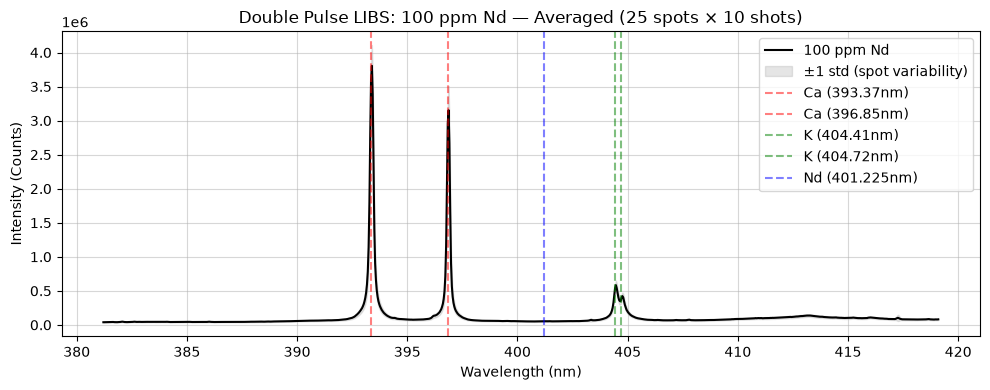

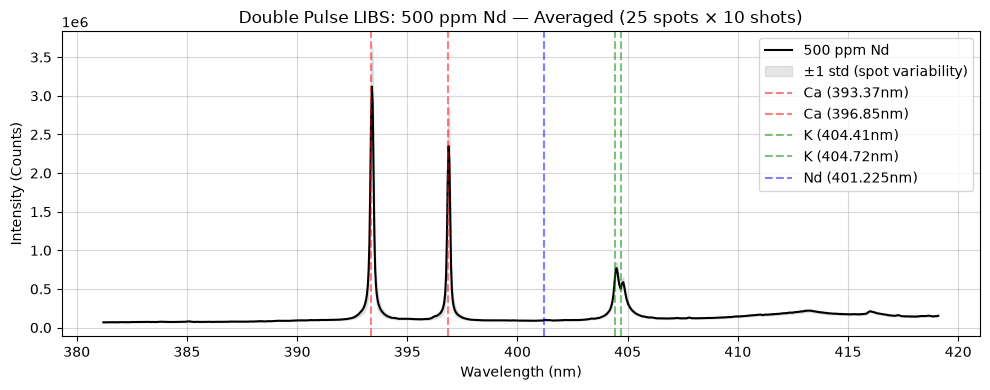

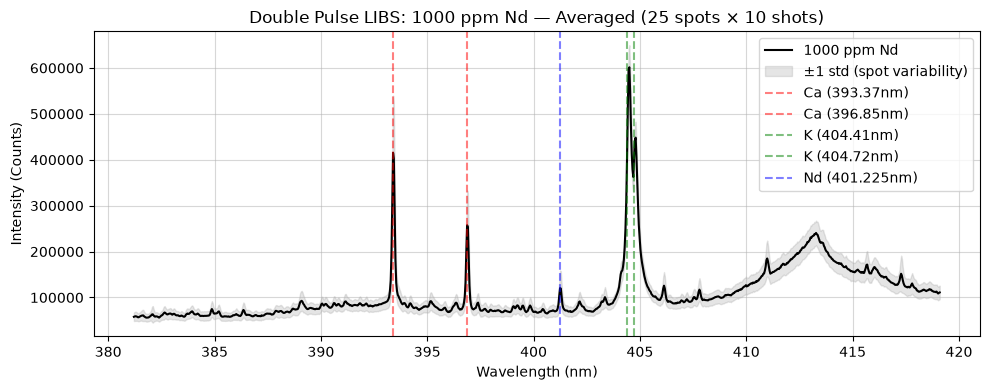

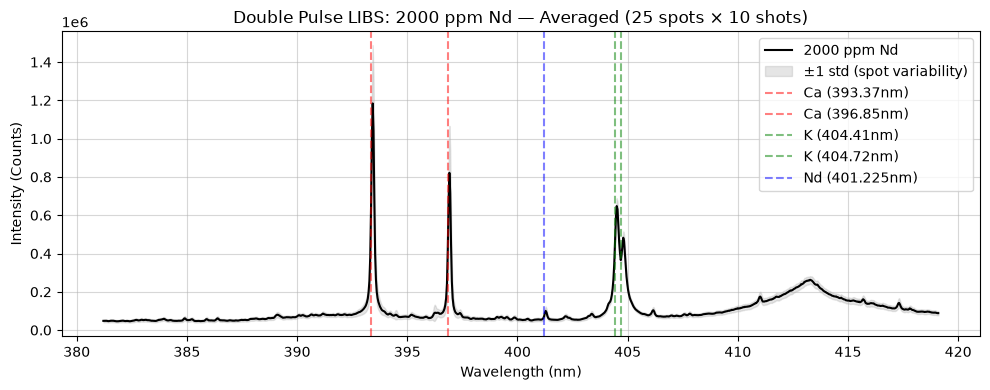

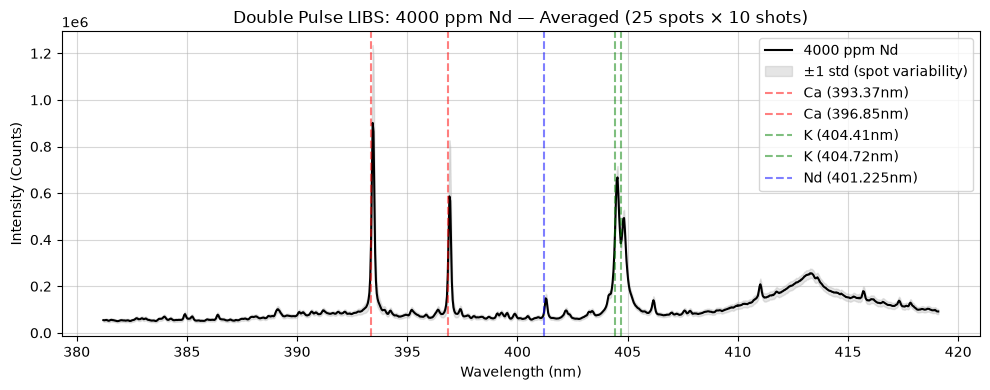

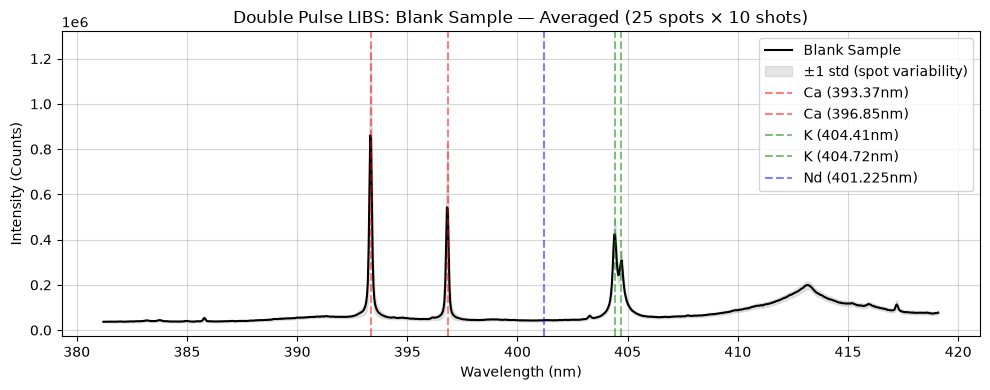

In [7]:
coeffs = [381.02184936261204, 0.037033476478940355, 0.0, 0.0]
drift_offset = 0.15

N_SPOTS = 25
N_SHOTS = 10
plasma_rows = slice(512, 600)

for filename, label in files_to_plot.items():
    file_path = os.path.join(base_folder, filename)
    data, info = sif_parser.np_open(file_path)

    # Verify shape
    assert data.shape[0] == N_SPOTS * N_SHOTS, \
        f"Expected {N_SPOTS * N_SHOTS} frames, got {data.shape[0]} in {filename}"

    # --- PROPER AVERAGING ---
    spot_spectra = []
    for spot in range(N_SPOTS):
        frames = data[spot * N_SHOTS : (spot + 1) * N_SHOTS]  # shape (10, 1024, 1024)
        frames = np.clip(frames, 0, None)                      # remove negative values
        plasma = frames[:, plasma_rows, :]                     # shape (10, 88, 1024)
        spectra = np.sum(plasma, axis=1)                       # sum vertically → (10, 1024)
        avg_spectrum = np.mean(spectra, axis=0)                # avg shots → (1024,)
        spot_spectra.append(avg_spectrum)

    spot_spectra = np.array(spot_spectra)          # shape (25, 1024)
    mean_spectrum = np.mean(spot_spectra, axis=0)  # shape (1024,) — representative spectrum
    std_spectrum  = np.std(spot_spectra, axis=0)   # shape (1024,) — spot-to-spot variability

    # Wavelength calibration
    pixels = np.arange(1, mean_spectrum.shape[0] + 1)
    wavelengths = coeffs[0] + (coeffs[1] * pixels) + drift_offset

    # --- PLOTTING ---
    plt.figure(figsize=(10, 4))
    plt.plot(wavelengths, mean_spectrum, linewidth=1.5, color='black', label=label)
    plt.fill_between(wavelengths,
                     mean_spectrum - std_spectrum,
                     mean_spectrum + std_spectrum,
                     alpha=0.2, color='gray', label='±1 std (spot variability)')

    # Reference lines
    plt.axvline(x=393.37, color='red',   linestyle='--', alpha=0.5, label='Ca (393.37nm)')
    plt.axvline(x=396.85, color='red',   linestyle='--', alpha=0.5, label='Ca (396.85nm)')
    plt.axvline(x=404.41, color='green', linestyle='--', alpha=0.5, label='K (404.41nm)')
    plt.axvline(x=404.72, color='green', linestyle='--', alpha=0.5, label='K (404.72nm)')
    plt.axvline(x=401.225, color='blue', linestyle='--', alpha=0.5, label='Nd (401.225nm)')

    plt.title(f"Double Pulse LIBS: {label} — Averaged (25 spots × 10 shots)")
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Intensity (Counts)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.5)
    plt.tight_layout()
    plt.show()

sample        ppm  n_det  R_med(Nd/K)       ±SE      R_avg
------------------------------------------------------------
blank         0.0   38/250      0.00303   0.00057    0.00205
5 ppm         5.1   18/250      0.00084   0.00044    0.00088
10 ppm       10.1   30/250      0.00219   0.00060    0.00103
50 ppm       50.2   32/250      0.00118   0.00045    0.00101
100 ppm     100.9   38/250      0.00296   0.00047    0.00278
500 ppm     500.0   94/250      0.00682   0.00048    0.00753
1000 ppm   1080.0  215/250      0.02313   0.00152    0.03392
2000 ppm   2032.9  250/250      0.02327   0.00094    0.02593
4000 ppm   3987.0  248/250      0.04588   0.00140    0.04588

wrote nd_k_per_shot.csv and nd_k_curve.png


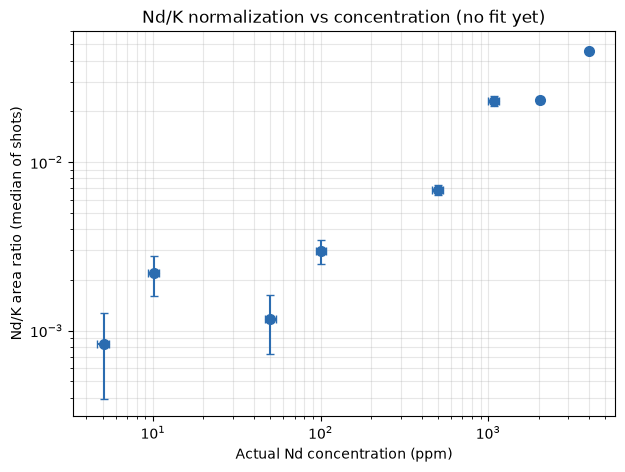

In [8]:
"""
Nd/K normalization pipeline for FLiNaK LIBS (DP).

Per shot: baseline-subtracted AREA of the Nd line and the K doublet -> ratio.
Aggregated per sample two ways (median-of-ratios primary; ratio-of-averages
cross-check). Writes a per-shot CSV (calibration points + CNN training data)
and an Nd/K-vs-actual-ppm scatter. NO curve fitting here -- that's the next step.

Why no per-shot recalibration: integration windows are ~0.8-1.7 nm wide and the
residual axis drift is ~0.1-0.2 nm, so every peak sits fully inside its window
regardless. Area is insensitive to sub-window axis shifts; centroids are not.
Why K is a safe denominator: it's a major-matrix line (~2e5 counts), so per-shot
ratios are well-conditioned -- no skew/inflation from a near-zero denominator.
"""
import os, csv
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

BASE_FOLDER = os.path.join('DP', 'DP')
ROI        = (512, 600)
OLD_COEFFS = [381.02184936261204 +.15, 0.037033476478940355, 0.0, 0.0]

ND_WIN    = (400.85, 401.70)   # Nd II 401.225; excludes the ~400.45 neighbor feature
K_WIN     = (403.70, 405.40)   # whole K I doublet as one window
NOISE_WIN = (401.75, 403.00)   # line-free patch -> per-shot noise sigma
EDGE      = 0.18
SNR_GATE  = 3.0
OUT = os.path.dirname(os.path.abspath('.'))

# (filename, label, actual_ppm, sd_ppm)  -- actual ppm from prep sheet
SAMPLES = [
    ('DP_blank_25_spot_scan.sif',        'blank',     0.0,   0.0),
    ('DP_5ppm_25_spot_scan.sif',         '5 ppm',     5.07,  0.42),
    ('DP_10ppm_25_spot_scan_1.sif',      '10 ppm',    10.1,  0.77),
    ('DP_50ppm_25_spot_scan.sif',        '50 ppm',    50.2,  3.68),
    ('DP_100ppm_25_spot_scan_1_old.sif', '100 ppm',   100.9, 7.4),
    ('DP_500ppm_25_spot_scan_old.sif',   '500 ppm',   500.0, 36.7),
    ('DP_1000ppm_25_spot_scan_3.sif',    '1000 ppm',  1080.0,79.2),
    ('DP_2000ppm_25_spot_scan.sif',      '2000 ppm',  2032.9,90.2),
    ('DP_4000ppm_25_spot_scan.sif',      '4000 ppm',  3987.0,88.0),
]

def _trapz(y, x):
    fn = getattr(np, "trapezoid", None) or getattr(np, "trapz", None)
    return fn(y, x) if fn else np.sum((y[:-1]+y[1:])*np.diff(x)/2.0)

def integrate_area(wl, spec, lo, hi, edge=EDGE):
    """Signed baseline-subtracted area. NOT clipped to >=0: clipping makes pure
    noise integrate to a positive floor, biasing the blank and low-conc points
    upward. Signed area keeps noise mean-zero so the blank reads ~0 and the
    calibration stays linear into the detection limit."""
    m = (wl >= lo) & (wl <= hi); x, y = wl[m], spec[m]
    if len(x) < 5: return np.nan
    bl_L = np.median(y[x < lo+edge]); bl_R = np.median(y[x > hi-edge])
    base = np.interp(x, [x[0], x[-1]], [bl_L, bl_R])
    return _trapz(y-base, x)

def peak_snr(wl, spec, win, noise_sigma, edge=EDGE):
    m = (wl >= win[0]) & (wl <= win[1]); x, y = wl[m], spec[m]
    bl = np.median(np.r_[y[x < win[0]+edge], y[x > win[1]-edge]])
    return (np.max(y) - bl) / noise_sigma if noise_sigma > 0 else np.nan

def mad_se(a):
    a = a[np.isfinite(a)]
    if len(a) < 2: return np.nan
    mad = 1.4826 * np.median(np.abs(a - np.median(a)))
    return 1.2533 * mad / np.sqrt(len(a))      # ~SE of the median

# ---------------------------------------------------------------- main loop
rows = []           # per-shot CSV
summary = []        # per-sample
print(f"{'sample':<9} {'ppm':>7} {'n_det':>6} {'R_med(Nd/K)':>12} {'±SE':>9} {'R_avg':>10}")
print("-"*60)

for fname, label, ppm, sd in SAMPLES:
    path = os.path.join(BASE_FOLDER, fname)
    if not os.path.exists(path):
        print(f"{label:<9}  MISSING: {path}"); continue
    import sif_parser
    data, _ = sif_parser.np_open(path)
    frames = data if data.ndim == 3 else data[None]
    pixels = np.arange(1, frames.shape[-1]+1)
    wl = np.polyval(OLD_COEFFS[::-1], pixels)

    # averaged-spectrum areas (cross-check estimator)
    avg_spec = np.sum(frames.mean(axis=0)[ROI[0]:ROI[1], :], axis=0).astype(float)
    Nd_avg = integrate_area(wl, avg_spec, *ND_WIN)
    K_avg  = integrate_area(wl, avg_spec, *K_WIN)
    R_avg  = Nd_avg / K_avg

    # per-shot
    ratios, ndet = [], 0
    for i, fr in enumerate(frames):
        spec = np.sum(fr[ROI[0]:ROI[1], :], axis=0).astype(float)
        noise = np.std(spec[(wl>=NOISE_WIN[0])&(wl<=NOISE_WIN[1])])
        Nd_i = integrate_area(wl, spec, *ND_WIN)
        K_i  = integrate_area(wl, spec, *K_WIN)
        r = Nd_i / K_i if K_i else np.nan
        snr = peak_snr(wl, spec, ND_WIN, noise)
        if np.isfinite(snr) and snr >= SNR_GATE: ndet += 1
        ratios.append(r)
        rows.append([label, ppm, i, Nd_i, K_i, r, snr])
    ratios = np.array(ratios)
    R_med, SE = np.nanmedian(ratios), mad_se(ratios)
    summary.append((label, ppm, sd, R_med, SE, R_avg, ndet, len(frames)))
    print(f"{label:<9} {ppm:>7.1f} {ndet:>4}/{len(frames)} {R_med:>12.5f} {SE:>9.5f} {R_avg:>10.5f}")

# ---------------------------------------------------------------- outputs
with open(os.path.join(OUT, 'nd_k_per_shot.csv'), 'w', newline='') as f:
    w = csv.writer(f)
    w.writerow(['sample','actual_ppm','shot','Nd_area','K_area','Nd_over_K','Nd_SNR'])
    w.writerows(rows)

# scatter: R_med vs actual ppm (excl. blank), prep SD as x-error
pts = [s for s in summary if s[1] > 0]
x   = np.array([s[1] for s in pts]); xe = np.array([s[2] for s in pts])
y   = np.array([s[3] for s in pts]); ye = np.array([s[4] for s in pts])
fig, ax = plt.subplots(figsize=(7,5))
ax.errorbar(x, y, xerr=xe, yerr=ye, fmt='o', ms=7, capsize=3, color='#2b6cb0')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Actual Nd concentration (ppm)'); ax.set_ylabel('Nd/K area ratio (median of shots)')
ax.set_title('Nd/K normalization vs concentration (no fit yet)')
ax.grid(True, which='both', alpha=0.3)
fig.savefig(os.path.join(OUT, 'nd_k_curve.png'), dpi=130)
print("\nwrote nd_k_per_shot.csv and nd_k_curve.png")

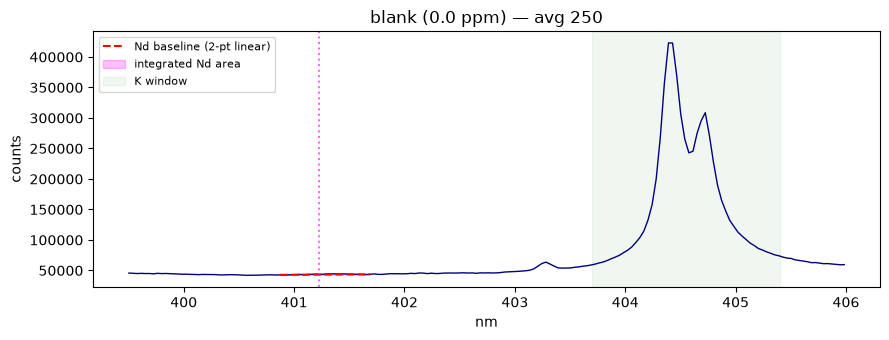

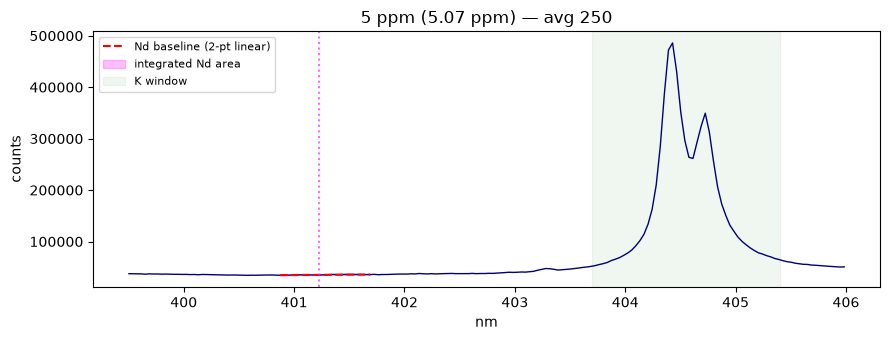

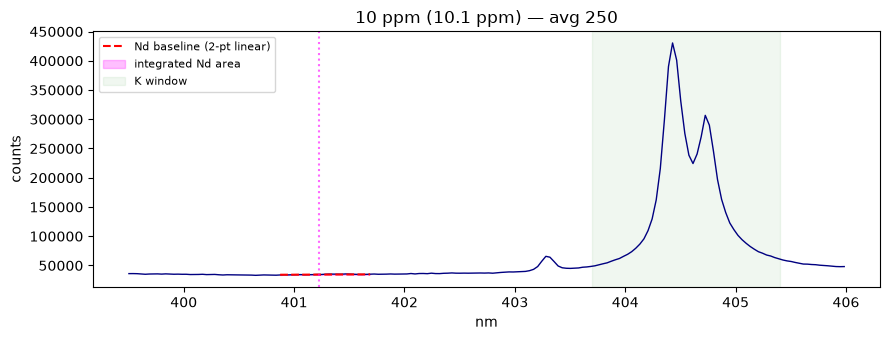

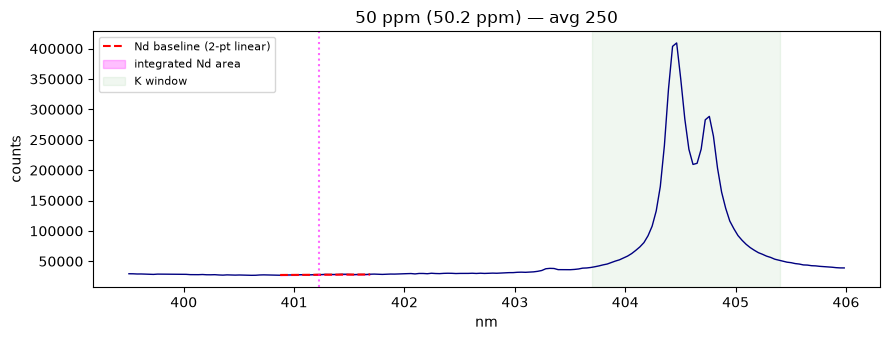

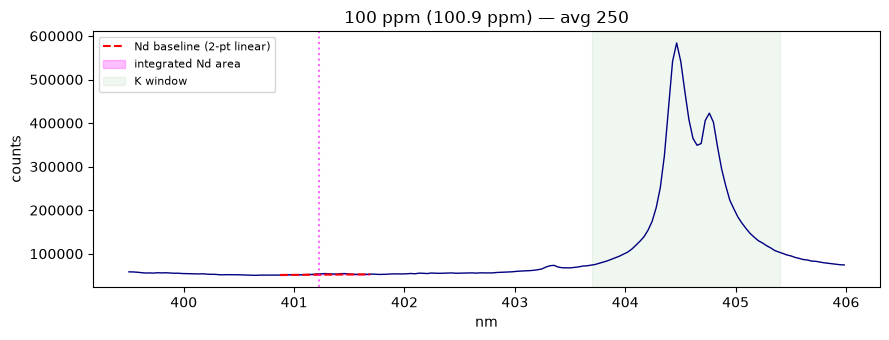

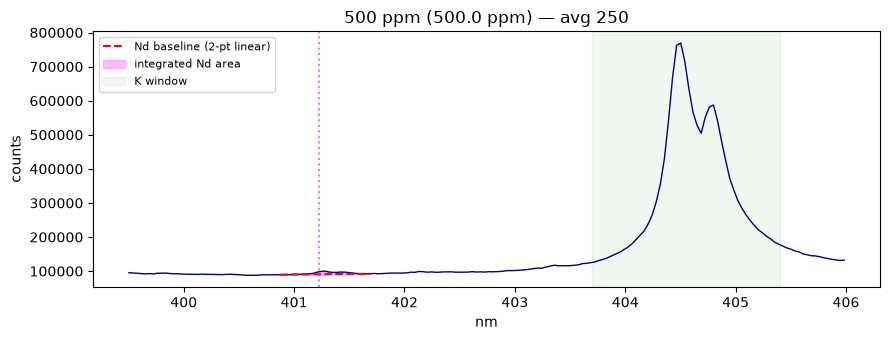

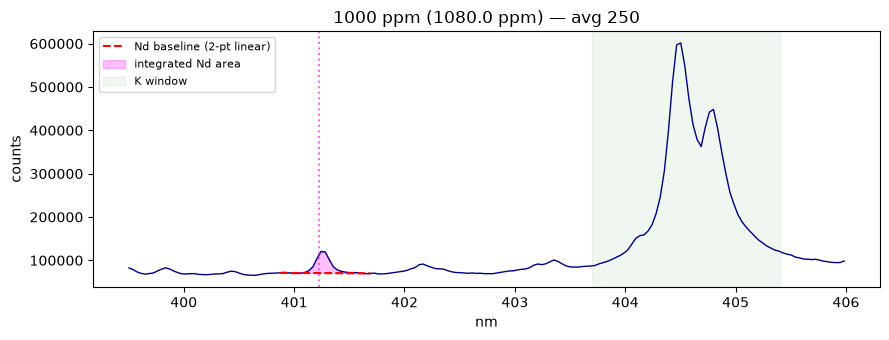

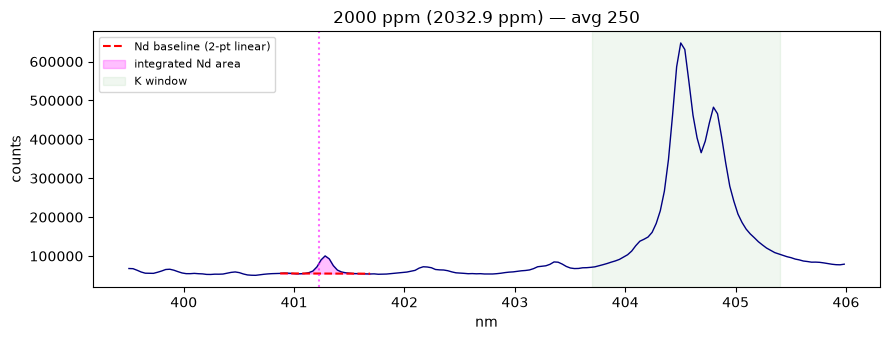

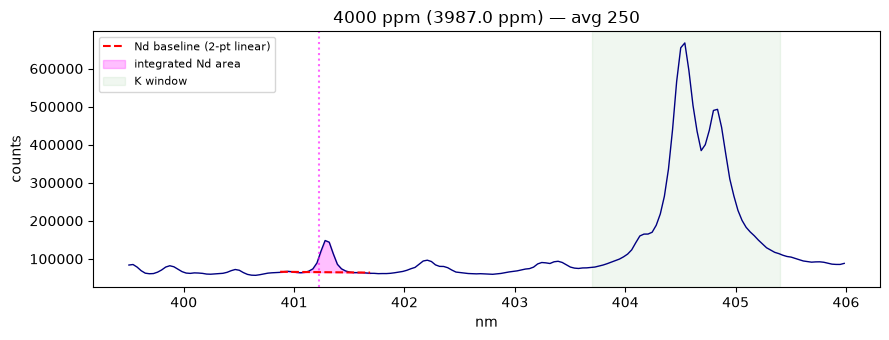

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt
VIEW    = (399.5, 406.0)   # Nd window + K context
AVERAGE = True             # set False to inspect a single noisy shot instead

def baseline_in_window(wl, spec, lo, hi, edge=EDGE):
    m = (wl >= lo) & (wl <= hi); x, y = wl[m], spec[m]
    blL = np.median(y[x < lo+edge]); blR = np.median(y[x > hi-edge])
    return m, np.interp(x, [x[0], x[-1]], [blL, blR])

for fname, label, ppm, sd in SAMPLES:
    data, _ = sif_parser.np_open(os.path.join(BASE_FOLDER, fname))
    frames = data if data.ndim == 3 else data[None]
    img    = frames.mean(axis=0) if AVERAGE else frames[0]
    spec   = np.sum(img[ROI[0]:ROI[1], :], axis=0).astype(float)
    pixels = np.arange(1, frames.shape[-1]+1); wl = np.polyval(OLD_COEFFS[::-1], pixels)
    v = (wl >= VIEW[0]) & (wl <= VIEW[1])
    ndm, base = baseline_in_window(wl, spec, *ND_WIN)

    plt.figure(figsize=(9, 3.5))
    plt.plot(wl[v], spec[v], color='navy', lw=1)
    plt.plot(wl[ndm], base, color='red', ls='--', lw=1.5, label='Nd baseline (2-pt linear)')
    plt.fill_between(wl[ndm], base, spec[ndm], alpha=.25, color='magenta', label='integrated Nd area')
    plt.axvspan(*K_WIN, color='green', alpha=.06, label='K window')
    plt.axvline(401.225, color='magenta', ls=':', alpha=.6)
    plt.title(f"{label} ({ppm} ppm) — {'avg 250' if AVERAGE else '1 shot'}")
    plt.xlabel('nm'); plt.ylabel('counts'); plt.legend(fontsize=8); plt.tight_layout(); plt.show()

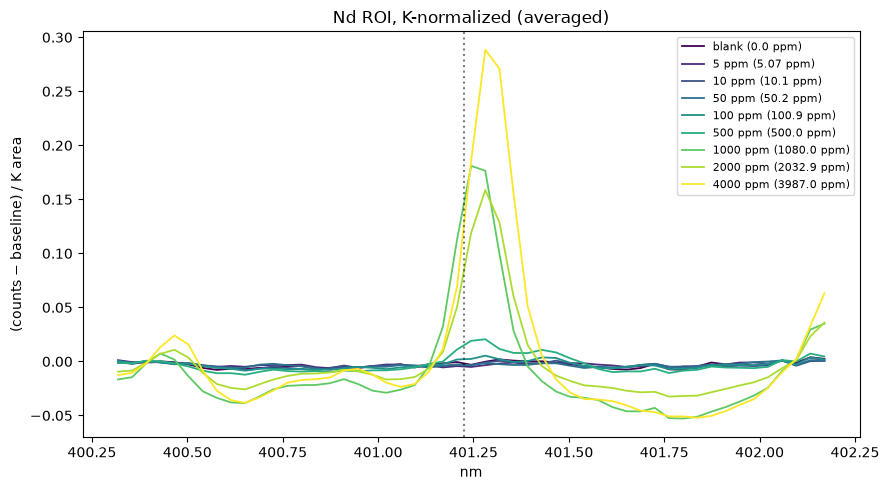

In [10]:
plt.figure(figsize=(9, 5))
cmap = plt.cm.viridis(np.linspace(0, 1, len(SAMPLES)))
for (fname, label, ppm, sd), c in zip(SAMPLES, cmap):
    data, _ = sif_parser.np_open(os.path.join(BASE_FOLDER, fname))
    frames = data if data.ndim == 3 else data[None]
    spec   = np.sum(frames.mean(axis=0)[ROI[0]:ROI[1], :], axis=0).astype(float)
    pixels = np.arange(1, frames.shape[-1]+1); wl = np.polyval(OLD_COEFFS[::-1], pixels)
    Karea  = integrate_area(wl, spec, *K_WIN)
    roi = (wl >= 400.3) & (wl <= 402.2)
    ndm, base = baseline_in_window(wl, spec, 400.3, 402.2)
    plt.plot(wl[roi], (spec[roi] - base) / Karea, color=c, lw=1.3, label=f"{label} ({ppm} ppm)")
plt.axvline(401.225, color='k', ls=':', alpha=.5)
plt.xlabel('nm'); plt.ylabel('(counts − baseline) / K area'); plt.title('Nd ROI, K-normalized (averaged)')
plt.legend(fontsize=8); plt.tight_layout(); plt.show()


In [12]:
import csv, numpy as np
ND_WIN=(400.85,401.70); K_WIN=(403.70,405.40); NOISE_WIN=(401.55,401.95)
GAP_L=(400.55,400.78); GAP_R=(401.55,401.95)   # verified clean continuum

def _t(y,x): 
    fn=getattr(np,"trapezoid",None) or getattr(np,"trapz",None); return fn(y,x)
def K_area(s): m=(wl>=K_WIN[0])&(wl<=K_WIN[1]); return _t(s[m],wl[m])

def nd_area_local(s):
    # baseline = line through the median of the two clean gaps (not window edges)
    mL=(wl>=GAP_L[0])&(wl<=GAP_L[1]); mR=(wl>=GAP_R[0])&(wl<=GAP_R[1])
    xL,xR=np.mean(wl[mL]),np.mean(wl[mR]); yL,yR=np.median(s[mL]),np.median(s[mR])
    m=(wl>=ND_WIN[0])&(wl<=ND_WIN[1])
    base=np.interp(wl[m],[xL,xR],[yL,yR])
    return _t(s[m]-base, wl[m])

rows=[]; print(f"{'sample':<9}{'ppm':>7}{'n_det':>7}{'R_med':>11}{'±SE':>10}{'R_avg':>11}")
print("-"*56)
for fname,label,ppm,sd in SAMPLES:
    d,_=sif_parser.np_open(os.path.join(BASE_FOLDER,fname))
    frames=d if d.ndim==3 else d[None]
    savg=np.sum(frames.mean(0)[ROI[0]:ROI[1],:],axis=0).astype(float)
    R_avg=nd_area_local(savg)/K_area(savg)
    rr=[]; ndet=0
    for i,fr in enumerate(frames):
        s=np.sum(fr[ROI[0]:ROI[1],:],axis=0).astype(float); Ks=K_area(s)
        nd=nd_area_local(s); r=nd/Ks; rr.append(r)
        noise=np.std(s[(wl>=NOISE_WIN[0])&(wl<=NOISE_WIN[1])])
        pk=np.max(s[(wl>=ND_WIN[0])&(wl<=ND_WIN[1])]) - np.median(s[(wl>=GAP_R[0])&(wl<=GAP_R[1])])
        if noise>0 and pk>3*noise: ndet+=1
        rows.append([label,ppm,i,nd,Ks,r])
    rr=np.array(rr); med=np.median(rr)
    mad=1.4826*np.median(np.abs(rr-med)); se=1.2533*mad/np.sqrt(len(rr))
    print(f"{label:<9}{ppm:>7.1f}{ndet:>4}/{len(frames)}{med:>11.5f}{se:>10.5f}{R_avg:>11.5f}")

with open('nd_k_final.csv','w',newline='') as f:
    w=csv.writer(f); w.writerow(['sample','actual_ppm','shot','Nd_area','K_area','Nd_over_K']); w.writerows(rows)
print("\nwrote nd_k_final.csv")

sample       ppm  n_det      R_med       ±SE      R_avg
--------------------------------------------------------
blank        0.0  55/250    0.00132   0.00040    0.00167
5 ppm        5.1  53/250    0.00042   0.00033    0.00040
10 ppm      10.1  67/250    0.00098   0.00036    0.00068
50 ppm      50.2  47/250    0.00057   0.00032    0.00004
100 ppm    100.9  69/250    0.00167   0.00030    0.00179
500 ppm    500.0 115/250    0.00403   0.00026    0.00419
1000 ppm  1080.0 231/250    0.01430   0.00093    0.02283
2000 ppm  2032.9 250/250    0.01730   0.00065    0.01979
4000 ppm  3987.0 250/250    0.03504   0.00086    0.03601

wrote nd_k_final.csv


In [29]:
import numpy as np
from lmfit.models import VoigtModel, LinearModel

ND_CENTER   = 401.225
CENTER_TOL  = 0.10                 # nm; center bound = ND_CENTER +/- CENTER_TOL
FIT_WIN     = (400.70, 401.85)     # excludes the 400.45 and 402.2 neighbor lines
NOISE_WIN   = (401.55, 401.95)     # line-free gap -> per-shot noise estimate
AMP_SNR_MIN = 3.0
REDCHI_LO, REDCHI_HI = 0.3, 3.0
FWHM_LO, FWHM_HI = 0.08, 0.20      # physically credible Nd width (strong-peak FWHM ~0.134)
PEAK_SCREEN_SNR = 3.0              # skip the fit entirely if window peak < this x noise
MAX_NFEV = 2000                    # hard iteration cap so hopeless fits bail fast

def measure_instrumental_sigma(wl, strong_spec, ref_center=396.847,
                               win=(396.35, 397.35)):
    """Fit a FREE Voigt to a strong isolated line; return its Gaussian sigma.
    CAVEAT: Stark broadening makes this an UPPER bound on instrumental sigma.
    Run on a high-SNR averaged spectrum, not a single shot."""
    m = (wl >= win[0]) & (wl <= win[1])
    x, y = wl[m], strong_spec[m]
    mod = VoigtModel(prefix='r_') + LinearModel(prefix='b_')
    p = mod.make_params()
    p['r_center'].set(value=ref_center, min=ref_center-0.3, max=ref_center+0.3)
    p['r_amplitude'].set(value=(y.max()-np.median(y)), min=0)
    p['r_sigma'].set(value=0.04, min=1e-3)
    p['r_gamma'].set(value=0.04, vary=True, expr='', min=1e-4)
    p['b_slope'].set(value=0.0); p['b_intercept'].set(value=np.median(y))
    out = mod.fit(y, p, x=x)
    return out.params['r_sigma'].value, out

def fit_nd_shot(wl, spec, sigma_inst):
    """Fit one shot's Nd window. Returns features + errors + flags.
    accepted = amplitude is trustworthy; fwhm_ok = WIDTH is trustworthy (separate)."""
    m = (wl >= FIT_WIN[0]) & (wl <= FIT_WIN[1])
    x, y = wl[m], spec[m]
    nmask = (wl >= NOISE_WIN[0]) & (wl <= NOISE_WIN[1])
    noise = np.std(spec[nmask]); noise = noise if noise > 0 else 1.0
    bg0 = np.median(y)

    # --- pre-screen: no peak -> skip the (slow, thrashing) fit entirely ---
    if (y.max() - bg0) < PEAK_SCREEN_SNR * noise:
        return dict(success=False, accepted=False, fwhm_ok=False,
                    noise=noise, reason='no_peak')

    mod = VoigtModel(prefix='nd_') + LinearModel(prefix='bg_')
    p = mod.make_params()
    p['nd_center'].set(value=ND_CENTER, min=ND_CENTER-CENTER_TOL, max=ND_CENTER+CENTER_TOL)
    p['nd_amplitude'].set(value=max((y.max()-bg0), 1.0)*sigma_inst*2.5, min=0)  # area-scale guess
    p['nd_sigma'].set(value=sigma_inst, vary=False)              # FIXED instrumental
    p['nd_gamma'].set(value=sigma_inst, vary=True, expr='', min=1e-4)  # FREE physical
    p['bg_slope'].set(value=0.0)
    p['bg_intercept'].set(value=bg0)

    try:
        out = mod.fit(y, p, x=x, weights=np.full_like(y, 1.0/noise), max_nfev=MAX_NFEV)
    except Exception as e:
        return dict(success=False, accepted=False, fwhm_ok=False,
                    noise=noise, reason=f'exception:{e}')

    P = out.params
    def val(n): return P[n].value
    def err(n): return P[n].stderr if P[n].stderr is not None else np.nan

    amp, amp_e = val('nd_amplitude'), err('nd_amplitude')
    cen        = val('nd_center')
    gamma_e    = err('nd_gamma')
    fwhm       = val('nd_fwhm')
    amp_snr    = amp/amp_e if (amp_e and amp_e > 0 and np.isfinite(amp_e)) else 0.0
    center_pinned = (cen <= ND_CENTER-CENTER_TOL+1e-3) or (cen >= ND_CENTER+CENTER_TOL-1e-3)
    redchi = out.redchi

    accepted = (out.success and amp_snr > AMP_SNR_MIN and (not center_pinned)
                and REDCHI_LO < redchi < REDCHI_HI)
    # width trustworthy only if it's physically credible AND its error is finite
    fwhm_ok = bool(accepted and (FWHM_LO < fwhm < FWHM_HI) and np.isfinite(gamma_e))

    return dict(
        success=out.success, accepted=accepted, fwhm_ok=fwhm_ok,
        amp=amp, amp_err=amp_e,
        height=val('nd_height'), height_err=err('nd_height'),
        center=cen, center_err=err('nd_center'),
        gamma=val('nd_gamma'), gamma_err=gamma_e,
        fwhm=fwhm, fwhm_err=err('nd_fwhm'),
        amp_snr=amp_snr, redchi=redchi, noise=noise,
    )

def batch_fit(samples, base_folder, roi, old_coeffs, sigma_inst,
              sif_parser, os, out_csv='nd_voigt_features.csv'):
    """samples: list of (filename, label, actual_ppm, sd). Writes the per-shot
    physics-feature table (the bottom branch of the model schematic)."""
    import csv, time
    pixels = None
    cols = ['sample','actual_ppm','shot','accepted','fwhm_ok','success',
            'amp','amp_err','height','height_err','center','center_err',
            'gamma','gamma_err','fwhm','fwhm_err','amp_snr','redchi']
    rows = []
    for fname, label, ppm, sd in samples:
        data, _ = sif_parser.np_open(os.path.join(base_folder, fname))
        frames = data if data.ndim == 3 else data[None]
        if pixels is None:
            pixels = np.arange(1, frames.shape[-1]+1)
            wl = np.polyval(old_coeffs[::-1], pixels)
        t0 = time.time(); nacc = nwid = 0
        for i, fr in enumerate(frames):
            spec = np.sum(fr[roi[0]:roi[1], :], axis=0).astype(float)
            r = fit_nd_shot(wl, spec, sigma_inst)
            nacc += int(r.get('accepted', False))
            nwid += int(r.get('fwhm_ok', False))
            rows.append([label, ppm, i, r.get('accepted'), r.get('fwhm_ok'), r.get('success'),
                         r.get('amp'), r.get('amp_err'), r.get('height'), r.get('height_err'),
                         r.get('center'), r.get('center_err'), r.get('gamma'), r.get('gamma_err'),
                         r.get('fwhm'), r.get('fwhm_err'), r.get('amp_snr'), r.get('redchi')])
        print(f"{label:<9} accepted {nacc:>3}/{len(frames)}   fwhm_ok {nwid:>3}/{len(frames)}   ({time.time()-t0:.1f}s)")
    with open(out_csv, 'w', newline='') as f:
        w = csv.writer(f); w.writerow(cols); w.writerows(rows)
    print(f"\nwrote {out_csv}")

In [30]:
batch_fit(SAMPLES, BASE_FOLDER, ROI, OLD_COEFFS, sigma_inst, sif_parser, os)

blank     accepted   0/250   fwhm_ok   0/250   (6.0s)
5 ppm     accepted   1/250   fwhm_ok   1/250   (5.3s)
10 ppm    accepted   1/250   fwhm_ok   1/250   (7.1s)
50 ppm    accepted   2/250   fwhm_ok   2/250   (4.9s)
100 ppm   accepted   4/250   fwhm_ok   4/250   (5.0s)
500 ppm   accepted  26/250   fwhm_ok  20/250   (7.5s)
1000 ppm  accepted 196/250   fwhm_ok 192/250   (5.6s)
2000 ppm  accepted 226/250   fwhm_ok 223/250   (5.5s)
4000 ppm  accepted 229/250   fwhm_ok 229/250   (3.8s)

wrote nd_voigt_features.csv


In [18]:
import numpy as np, sif_parser, os

px = np.arange(1,1025); wl = np.polyval(OLD_COEFFS[::-1], px)
def avg_spec(label):
    fn = next(f for f,l,*_ in SAMPLES if l==label)
    d,_ = sif_parser.np_open(os.path.join(BASE_FOLDER, fn))
    fr = d if d.ndim==3 else d[None]
    return np.sum(fr.mean(0)[ROI[0]:ROI[1],:], axis=0).astype(float)

sigma_inst, out = measure_instrumental_sigma(wl, avg_spec('4000 ppm'))
print('instrumental sigma =', round(sigma_inst,4), 'nm')
print(out.fit_report())

instrumental sigma = 0.0455 nm
[[Model]]
    (Model(voigt, prefix='r_') + Model(linear, prefix='b_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 52
    # data points      = 27
    # variables        = 6
    chi-square         = 6.9993e+08
    reduced chi-square = 33330164.1
    Akaike info crit   = 472.907792
    Bayesian info crit = 480.682813
    R-squared          = 0.99877690
[[Variables]]
    r_amplitude:  88185.2206 +/- 2425.88294 (2.75%) (init = 490551.4)
    r_center:     396.926111 +/- 5.7268e-04 (0.00%) (init = 396.847)
    r_sigma:      0.04548704 +/- 0.00245462 (5.40%) (init = 0.04)
    b_slope:     -13004.3879 +/- 4212.51297 (32.39%) (init = 0)
    b_intercept:  5240252.73 +/- 1670950.23 (31.89%) (init = 95285.2)
    r_gamma:      0.02477740 +/- 0.00386791 (15.61%) (init = 0.04)
    r_fwhm:       0.13605964 +/- 0.00173232 (1.27%) == '1.0692*r_gamma+sqrt(0.8664*r_gamma**2+5.545083*r_sigma**2)'
    r_height:     525665.609 +/- 5643.29744 (1.

In [27]:
import time
fn = next(f for f,l,*_ in SAMPLES if l=='blank')
t=time.time(); d,_ = sif_parser.np_open(os.path.join(BASE_FOLDER, fn)); print(f"load: {time.time()-t:.1f}s")
frames = d if d.ndim==3 else d[None]
t=time.time()
for i,fr in enumerate(frames):
    spec = np.sum(fr[ROI[0]:ROI[1],:], axis=0).astype(float)
    r = fit_nd_shot(wl, spec, sigma_inst)
print(f"250 fits: {time.time()-t:.1f}s")

load: 0.6s
250 fits: 89.9s


In [19]:
for lab in ['4000 ppm','500 ppm','blank']:
    s = avg_spec(lab)
    r = fit_nd_shot(wl, s, sigma_inst)
    print(f"{lab:<9} accepted={r['accepted']}  amp={r.get('amp'):.0f}±{r.get('amp_err'):.0f}  "
          f"center={r.get('center'):.3f}  fwhm={r.get('fwhm'):.4f}  redchi={r.get('redchi'):.2f}")

4000 ppm  accepted=True  amp=14506±293  center=401.296  fwhm=0.1340  redchi=1.18
500 ppm   accepted=True  amp=4112±723  center=401.310  fwhm=0.3140  redchi=1.47
blank     accepted=False  amp=579±nan  center=401.325  fwhm=0.3267  redchi=0.26


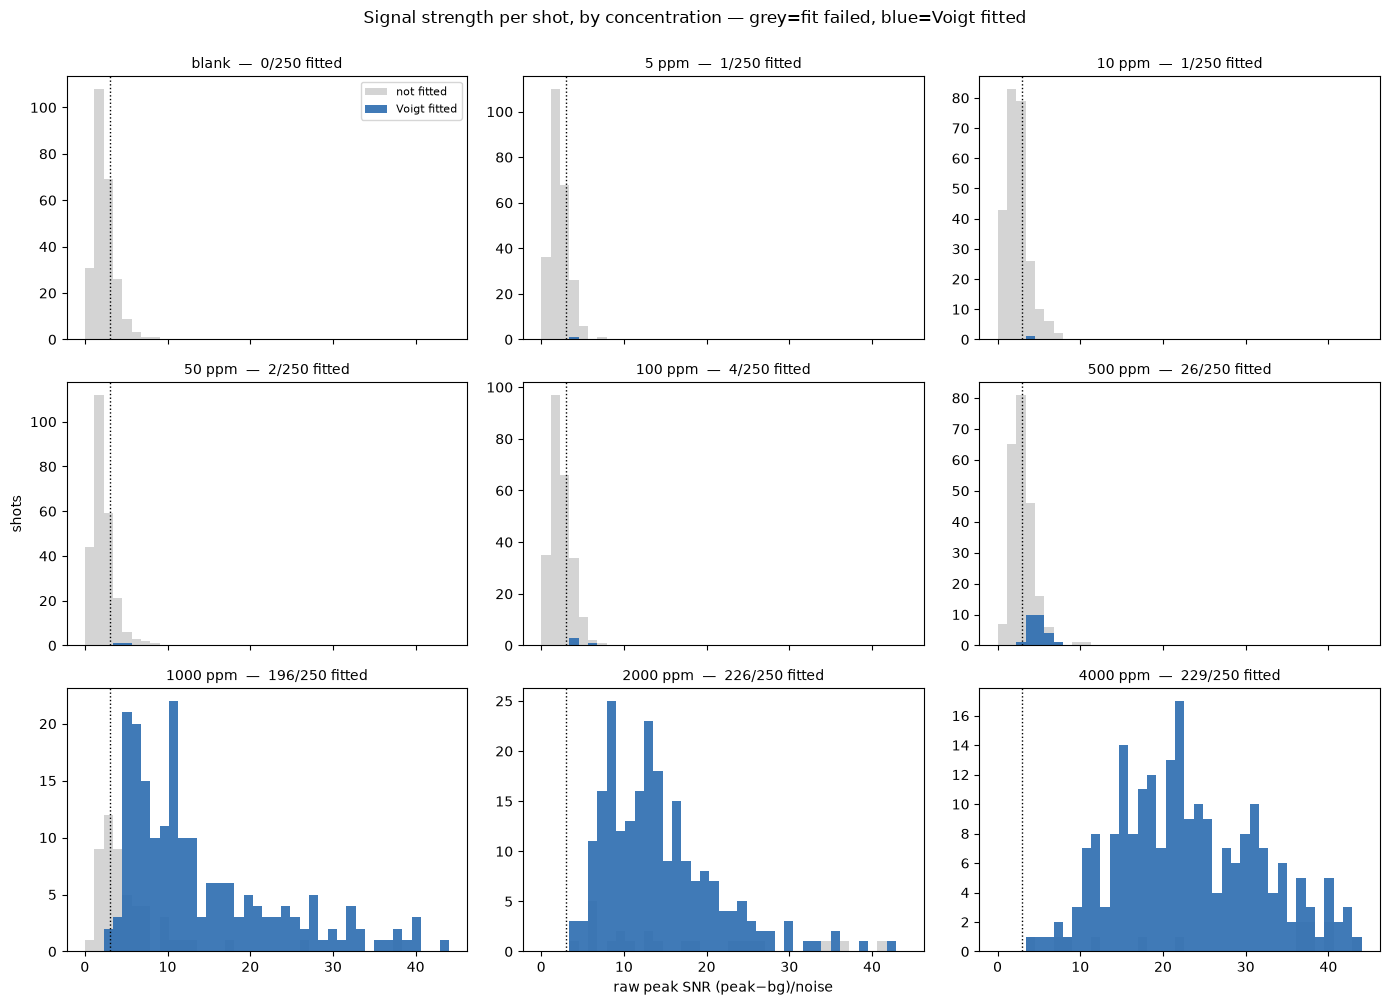

In [34]:
import numpy as np, matplotlib.pyplot as plt, sif_parser, os
import pandas as pd

# --- recompute a RAW signal proxy for EVERY shot (fit-independent) ---
px = np.arange(1,1025); wl = np.polyval(OLD_COEFFS[::-1], px)
ND_WIN, NOISE_WIN = (400.85,401.70), (401.55,401.95)
ndm  = (wl>=ND_WIN[0])&(wl<=ND_WIN[1])
noim = (wl>=NOISE_WIN[0])&(wl<=NOISE_WIN[1])

rows=[]
for fname,label,ppm,sd in SAMPLES:
    d,_ = sif_parser.np_open(os.path.join(BASE_FOLDER,fname))
    frames = d if d.ndim==3 else d[None]
    for i,fr in enumerate(frames):
        spec = np.sum(fr[ROI[0]:ROI[1],:],axis=0).astype(float)
        bg = np.median(spec[noim]); noise = np.std(spec[noim]) or 1.0
        raw_snr = (spec[ndm].max()-bg)/noise          # peak-over-noise, every shot
        rows.append((label,ppm,i,raw_snr))
raw = pd.DataFrame(rows,columns=['sample','ppm','shot','raw_snr'])

# merge the accepted flag from the feature table
feat = pd.read_csv('nd_voigt_features.csv')
feat['accepted'] = feat['accepted'].astype(str).str.strip().eq('True')
raw = raw.merge(feat[['sample','shot','accepted']], on=['sample','shot'], how='left')

# --- small-multiples: one panel per concentration ---
order = ['blank','5 ppm','10 ppm','50 ppm','100 ppm','500 ppm','1000 ppm','2000 ppm','4000 ppm']
order = [s for s in order if s in raw['sample'].unique()]
bins = np.linspace(0, raw['raw_snr'].quantile(0.99), 40)

fig, axes = plt.subplots(3, 3, figsize=(14,10), sharex=True)
for ax, s in zip(axes.ravel(), order):
    sub = raw[raw['sample']==s]
    ax.hist(sub.loc[~sub.accepted.fillna(False),'raw_snr'], bins=bins,
            color='#d0d0d0', label='not fitted', alpha=0.9)
    ax.hist(sub.loc[sub.accepted.fillna(False),'raw_snr'], bins=bins,
            color='#2b6cb0', label='Voigt fitted', alpha=0.9)
    nacc = int(sub.accepted.fillna(False).sum())
    ax.axvline(3, color='k', ls=':', lw=1)        # rough detection threshold
    ax.set_title(f'{s}  —  {nacc}/{len(sub)} fitted', fontsize=10)
    ax.set_yscale('linear')                           # log y so the 1-2 fitted shots show
for ax in axes.ravel()[len(order):]: ax.axis('off')
axes[1,0].set_ylabel('shots'); axes[2,1].set_xlabel('raw peak SNR (peak−bg)/noise')
axes[0,0].legend(fontsize=8)
plt.suptitle('Signal strength per shot, by concentration — grey=fit failed, blue=Voigt fitted',y=1.0)
plt.tight_layout(); plt.show()

/var/folders/24/wlm5ll7n44lg5xczyn2496bm0000gn/T/ipykernel_36910/2002377570.py:62: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(); plt.show()


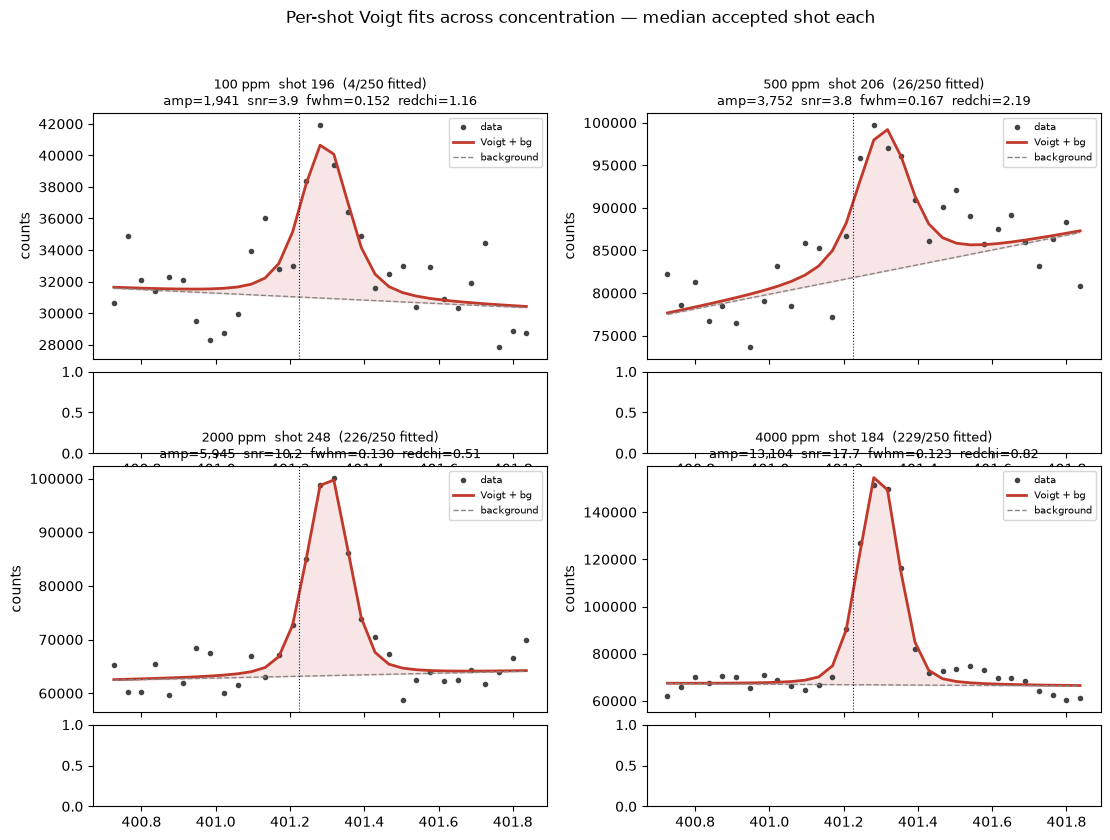

In [36]:
import numpy as np, matplotlib.pyplot as plt, pandas as pd, sif_parser, os
import matplotlib.gridspec as gridspec
from lmfit.models import VoigtModel, LinearModel

px = np.arange(1,1025); WL = np.polyval(OLD_COEFFS[::-1], px)
FIT_WIN=(400.70,401.85); NOISE_WIN=(401.55,401.95); ND_C=401.225; CTOL=0.10

def refit(spec, sigma_inst):
    m=(WL>=FIT_WIN[0])&(WL<=FIT_WIN[1]); x,y=WL[m],spec[m]
    nm=(WL>=NOISE_WIN[0])&(WL<=NOISE_WIN[1]); noise=np.std(spec[nm]) or 1.0
    bg0=np.median(y)
    mod=VoigtModel(prefix='nd_')+LinearModel(prefix='bg_'); p=mod.make_params()
    p['nd_center'].set(ND_C,min=ND_C-CTOL,max=ND_C+CTOL)
    p['nd_amplitude'].set(max((y.max()-bg0),1)*sigma_inst*2.5,min=0)
    p['nd_sigma'].set(sigma_inst,vary=False)
    p['nd_gamma'].set(sigma_inst,vary=True,expr='',min=1e-4)
    p['bg_slope'].set(0); p['bg_intercept'].set(bg0)
    out=mod.fit(y,p,x=x,weights=np.full_like(y,1/noise),max_nfev=2000)
    return x,y,out,noise

feat=pd.read_csv('nd_voigt_features.csv')
feat['accepted']=feat['accepted'].astype(str).str.strip().eq('True')

targets=['100 ppm','500 ppm','2000 ppm','4000 ppm']
pick={}
for s in targets:
    a=feat[(feat['sample']==s)&feat['accepted']].copy()
    if len(a)==0:                                   # nothing fit -> show strongest raw attempt
        a=feat[feat['sample']==s].copy()
        pick[s]=(int(a.loc[a['amp_snr'].astype(float).idxmax(),'shot']), 0)
    else:
        a=a.sort_values('amp_snr')
        pick[s]=(int(a.iloc[len(a)//2]['shot']), len(a))   # median-snr accepted shot, + count

def get_spec(sample,shot):
    fname=next(f for f,l,*_ in SAMPLES if l==sample)
    d,_=sif_parser.np_open(os.path.join(BASE_FOLDER,fname))
    fr=d if d.ndim==3 else d[None]
    return np.sum(fr[shot][ROI[0]:ROI[1],:],axis=0).astype(float)

fig=plt.figure(figsize=(13,9))
gs=gridspec.GridSpec(4,2,height_ratios=[3,1,3,1],hspace=0.08,wspace=0.22)
positions=[(0,0),(0,1),(2,0),(2,1)]
for (r,c),s in zip(positions,targets):
    shot,nacc=pick[s]; spec=get_spec(s,shot)
    x,y,out,noise=refit(spec,sigma_inst); P=out.params
    comp=out.eval_components(x=x)                    # {'nd_':..., 'bg_':...}
    axm=fig.add_subplot(gs[r,c]); axr=fig.add_subplot(gs[r+1,c],sharex=axm)
    axm.plot(x,y,'o',ms=3,color='#444',label='data')
    axm.plot(x,out.best_fit,'-',color='#c0392b',lw=2,label='Voigt + bg')
    axm.plot(x,comp['bg_'],'--',color='#888',lw=1,label='background')
    axm.fill_between(x,comp['bg_'],comp['bg_']+comp['nd_'],color='#c0392b',alpha=0.12)
    axm.axvline(401.225,color='b',ls=':',lw=0.8)
    amp=P['nd_amplitude'].value; ae=P['nd_amplitude'].stderr or np.nan
    snr=amp/ae if (ae==ae and ae>0) else np.nan
    tag=f"{nacc}/250 fitted" if nacc else "RARE success (<2% of sample)"
    axm.set_title(f"{s}  shot {shot}  ({tag})\namp={amp:,.0f}  snr={snr:.1f}  "
                  f"fwhm={P['nd_fwhm'].value:.3f}  redchi={out.redchi:.2f}",fontsize=9)
    axm.legend(fontsize=7,loc='upper right'); axm.tick_params(labelbottom=False)
    axm.set_ylabel('counts')
plt.suptitle('Per-shot Voigt fits across concentration — median accepted shot each',y=0.995)
plt.tight_layout(); plt.show()

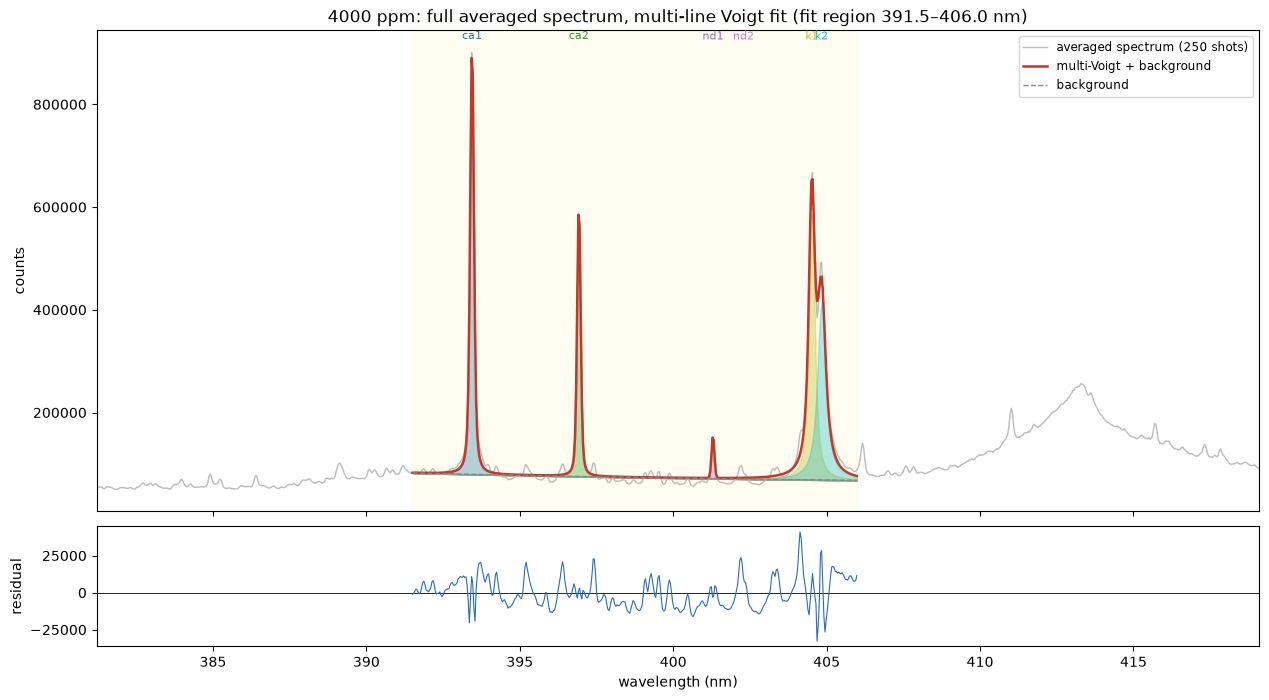

[[Model]]
    ((((((Model(parabolic, prefix='bg_') + Model(voigt, prefix='ca1_')) + Model(voigt, prefix='ca2_')) + Model(voigt, prefix='nd1_')) + Model(voigt, prefix='nd2_')) + Model(voigt, prefix='k1_')) + Model(voigt, prefix='k2_'))
[[Fit Statistics]]
    # fitting method   = leastsq
    # function evals   = 5000
    # data points      = 392
    # variables        = 21
    chi-square         = 4.0450e+10
    reduced chi-square = 1.0903e+08
    Akaike info crit   = 7275.21082
    Bayesian info crit = 7358.60732
    R-squared          = 0.99238626
##  Warning: uncertainties could not be estimated:
[[Variables]]
    bg_a:           28.1817043 (init = 0)
    bg_b:          -23448.6489 (init = 0)
    bg_c:           4942849.10 (init = 81480.83)
    ca1_amplitude:  161410.828 (init = 93219.52)
    ca1_center:     393.444199 (init = 393.366)
    ca1_sigma:      0.04548704 (fixed)
    ca1_gamma:      0.03573567 (init = 0.04548704)
    ca1_fwhm:       0.15036737 == '1.0692*ca1_gamma+sqrt(0.86

In [37]:
import numpy as np, matplotlib.pyplot as plt, sif_parser, os
from lmfit.models import VoigtModel, QuadraticModel

SAMPLE = '4000 ppm'              # change to any label to see other concentrations
FIT_LO, FIT_HI = 391.5, 406.0    # line-rich region (Ca II 393 -> K I 405)

px = np.arange(1,1025); WL = np.polyval(OLD_COEFFS[::-1], px)
fname = next(f for f,l,*_ in SAMPLES if l==SAMPLE)
d,_ = sif_parser.np_open(os.path.join(BASE_FOLDER, fname))
frames = d if d.ndim==3 else d[None]
spec = np.sum(frames.mean(0)[ROI[0]:ROI[1],:], axis=0).astype(float)   # averaged 1-D spectrum
nframes = len(frames)

LINES = [('ca1',393.366),('ca2',396.847),('nd1',401.225),
         ('nd2',402.2),('k1',404.414),('k2',404.721)]   # nd2 ~402.2 is approximate

m = (WL>=FIT_LO)&(WL<=FIT_HI); x,y = WL[m], spec[m]; bg0 = np.median(y)
model = QuadraticModel(prefix='bg_')
params = model.make_params(bg_a=0, bg_b=0, bg_c=bg0)
for pre,c0 in LINES:
    v = VoigtModel(prefix=pre+'_'); model = model + v
    w = (x>c0-0.2)&(x<c0+0.2)
    h = max(y[w].max()-bg0, 1.0) if w.any() else 1.0
    params.update(v.make_params())
    params[pre+'_center'].set(c0, min=c0-0.15, max=c0+0.15)
    params[pre+'_sigma'].set(sigma_inst, vary=False)              # instrumental, fixed
    params[pre+'_gamma'].set(sigma_inst, vary=True, expr='', min=1e-4)  # physical, free
    params[pre+'_amplitude'].set(h*sigma_inst*2.5, min=0)

out = model.fit(y, params, x=x, max_nfev=5000)
comp = out.eval_components(x=x)

fig = plt.figure(figsize=(15,8))
gs = fig.add_gridspec(2,1,height_ratios=[4,1],hspace=0.05)
ax = fig.add_subplot(gs[0]); axr = fig.add_subplot(gs[1],sharex=ax)
ax.plot(WL, spec, color='#bbb', lw=1, label=f'averaged spectrum ({nframes} shots)')
ax.plot(x, out.best_fit, color='#c0392b', lw=1.8, label='multi-Voigt + background')
ax.plot(x, comp['bg_'], '--', color='#888', lw=1, label='background')
colors = plt.cm.tab10(np.linspace(0,1,len(LINES)))
for (pre,c0),col in zip(LINES,colors):
    ax.fill_between(x, comp['bg_'], comp['bg_']+comp[pre+'_'], color=col, alpha=0.35)
    ax.annotate(pre, xy=(out.params[pre+'_center'].value, ax.get_ylim()[1]),
                fontsize=8, color=col, ha='center', va='top')
ax.axvspan(FIT_LO,FIT_HI,color='gold',alpha=0.05)
ax.set_xlim(WL.min(),WL.max()); ax.set_ylabel('counts')
ax.set_title(f'{SAMPLE}: full averaged spectrum, multi-line Voigt fit (fit region {FIT_LO}–{FIT_HI} nm)')
ax.legend(fontsize=8.5, loc='upper right'); ax.tick_params(labelbottom=False)
axr.axhline(0,color='k',lw=0.6); axr.plot(x, y-out.best_fit, color='#2b6cb0', lw=0.8)
axr.set_xlabel('wavelength (nm)'); axr.set_ylabel('residual')
plt.show()
print(out.fit_report(min_correl=0.5))